# Case Study: Sleep Deprivation Study (GAMM)

Analyze classic sleep deprivation data with random slopes.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import requests

from aurora.models.gamm import fit_gamm

def _download_file(url: str, output_path: str) -> None:
    """Download file from URL with progress indicator."""
    print(f"Downloading from {url}...")
    response = requests.get(url, stream=True)
    response.raise_for_status()

    total_size = int(response.headers.get('content-length', 0))
    downloaded = 0

    with open(output_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
            downloaded += len(chunk)
            if total_size > 0:
                percent = (downloaded / total_size) * 100
                print(f"\rProgress: {percent:.1f}%", end='', flush=True)

    print(f"\n✓ Downloaded to {output_path}")
    
def load_sleepstudy_data(
    cache_dir: str = '../data', force_download: bool = False
) -> pd.DataFrame:
    """
    Load sleep deprivation study dataset.

    Source: lme4 R package
    License: GPL-2
    URL: https://github.com/vincentarelbundock/Rdatasets

    Classic longitudinal dataset from a sleep deprivation study. Reaction time
    was measured for subjects with restricted sleep (3 hours per night).
    Useful for demonstrating longitudinal GAMM with random slopes.

    Parameters
    ----------
    cache_dir : str, default='../data'
        Directory to cache downloaded data
    force_download : bool, default=False
        Force re-download even if cached

    Returns
    -------
    df : DataFrame
        Sleep study data with columns:
        - reaction: Average reaction time (ms)
        - days: Days of sleep deprivation (0-9)
        - subject: Subject identifier (18 subjects)

    Notes
    -----
    Original study: Belenky et al. (2003). "Patterns of performance degradation
    and restoration during sleep restriction and subsequent recovery"

    Examples
    --------
    >>> df = load_sleepstudy_data()
    >>> print(df.shape)
    (180, 3)
    >>> print(df.groupby('subject').size())
    """
    cache_path = Path(cache_dir) / 'sleepstudy.csv'

    if not cache_path.exists() or force_download:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"
        _download_file(url, cache_path)
    else:
        print(f"✓ Using cached data: {cache_path}")

    df = pd.read_csv(cache_path)

    # Clean column names and remove index column if present
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])

    df = df.rename(
        columns={'Reaction': 'reaction', 'Days': 'days', 'Subject': 'subject'}
    )

    return df

df = load_sleepstudy_data()
print(f'Loaded {len(df)} sleep measurements')
print(f'Subjects: {df["subject"].nunique()}')
print(df.head())

✓ Using cached data: ../data/sleepstudy.csv
Loaded 180 sleep measurements
Subjects: 18
   rownames  reaction  days  subject
0         1  249.5600     0      308
1         2  258.7047     1      308
2         3  250.8006     2      308
3         4  321.4398     3      308
4         5  356.8519     4      308


In [2]:
# GAMM with random intercepts + slopes using formula interface
from aurora.models.gamm import (
    interpret_variance_components,
    compute_r2_conditional_marginal
)

result = fit_gamm(
    formula='reaction ~ days + (1 + days | subject)',
    data=df,
    family='gaussian',
    covariance='unstructured',
    maxiter=100,
    tol=1e-6
)

# Use the new summary() method
print(result.summary())

# Interpret variance components in detail
print('\n')
print(interpret_variance_components(
    result.variance_components,
    list(result.random_effects.keys())
))

# Compute R² statistics
r2_marginal, r2_conditional = compute_r2_conditional_marginal(result)
print(f'\nVarianza Explicada (R²):')
print(f'  R² marginal (efectos fijos):              {r2_marginal:.3f}')
print(f'  R² condicional (fijos + aleatorios):      {r2_conditional:.3f}')
print(f'\n  Interpretación:')
print(f'    - Los efectos fijos (días) explican {r2_marginal*100:.1f}% de la varianza')
print(f'    - Los efectos fijos + aleatorios explican {r2_conditional*100:.1f}% de la varianza')
print(f'    - Los efectos aleatorios añaden {(r2_conditional-r2_marginal)*100:.1f}% explicativo')

Generalized Additive Mixed Model (GAMM)
Family: gaussian
Number of observations: 180
Number of groups: 18

Fixed Effects (Parametric):
---------------------------------------------------------------------------
Parameter                     Estimate
---------------------------------------------------------------------------
β0                            251.4051
β1                             10.4673

Random Effects:
---------------------------------------------------------------------------
Group: subject
  Variance-Covariance Matrix:
      613.4871      9.8548
        9.8548     35.0543
  Standard Deviations:
    Component 0: 24.7687
    Component 1: 5.9207
  Correlation Matrix:
        1.0000      0.0672
        0.0672      1.0000

Residual Standard Deviation: 25.5881

Model Fit Statistics:
---------------------------------------------------------------------------
  Log-likelihood:           -871.81
  AIC:                      1819.59
  BIC:                      1940.87
  Effective

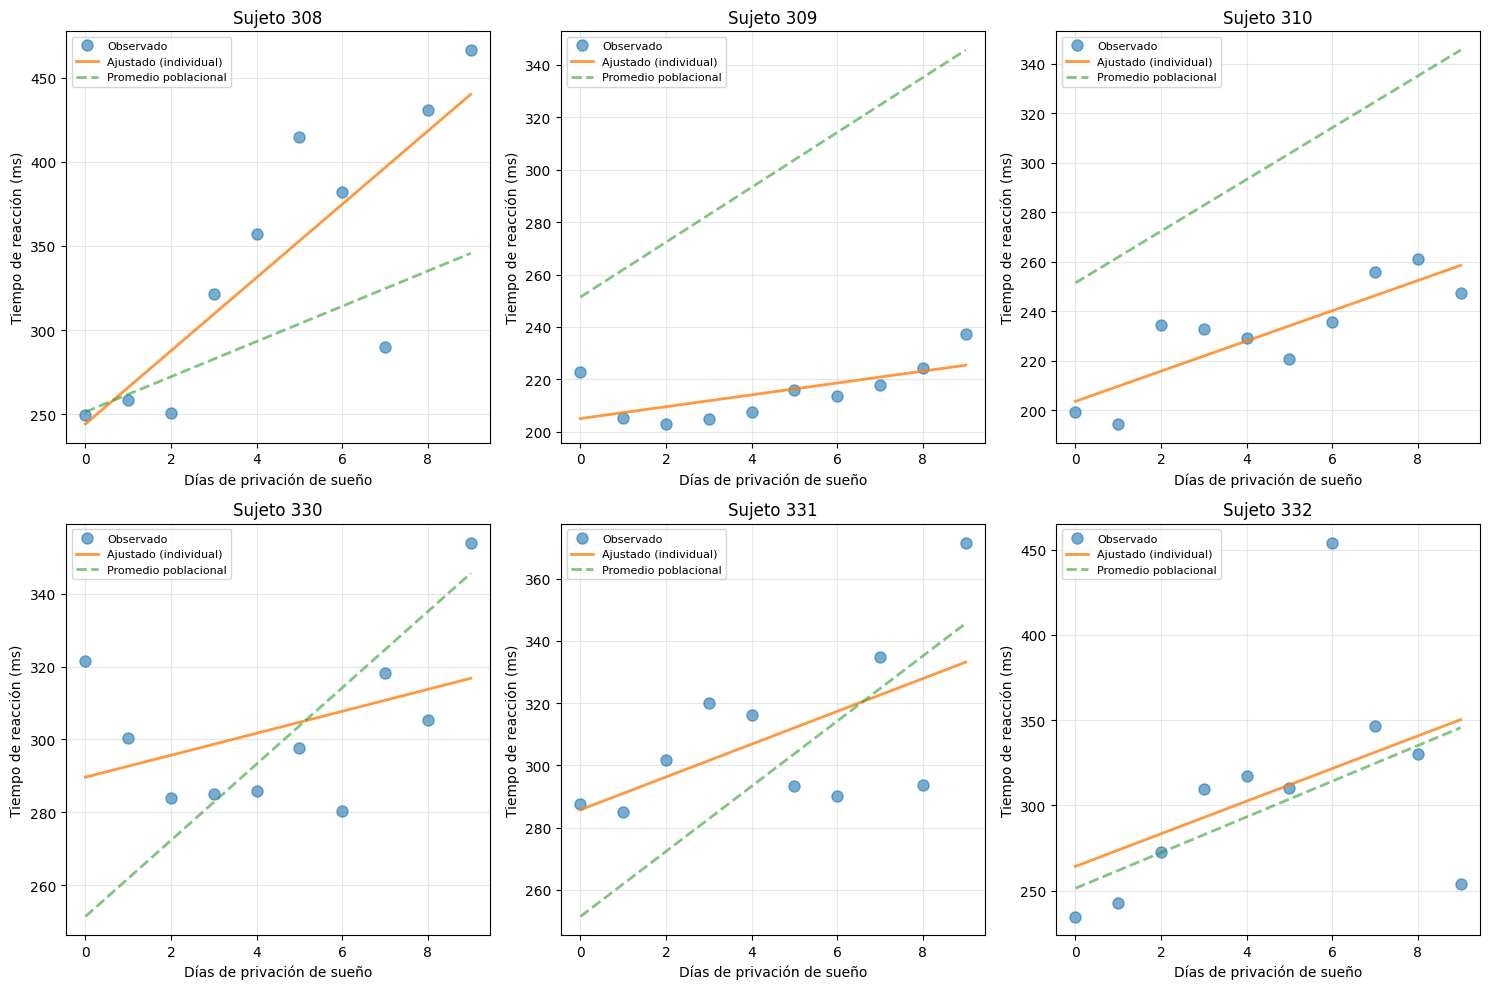

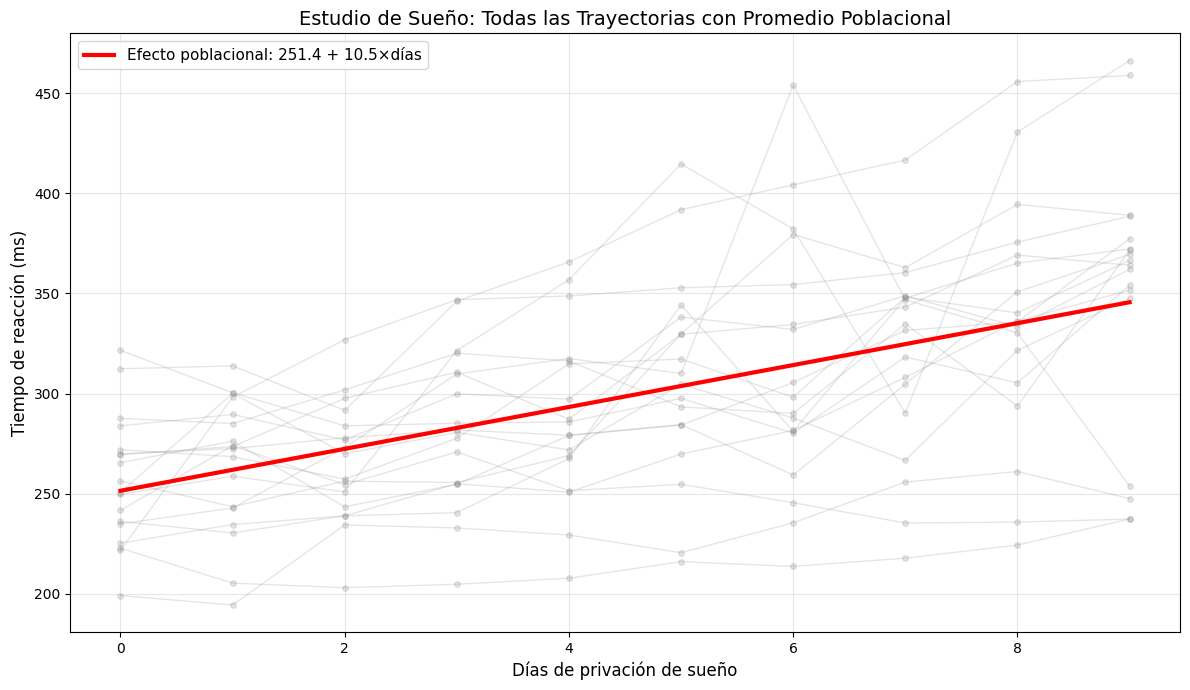


Interpretación de Trayectorias:
• Efecto fijo (poblacional): +10.5 ms por día de privación
• Intercepto promedio: 251.4 ms en día 0
• Variabilidad entre sujetos: Las líneas grises muestran diferencias individuales
• Algunos sujetos son consistentemente más rápidos/lentos que el promedio
• Algunos sujetos se deterioran más/menos rápido que el promedio


In [3]:
# Visualize subject trajectories with fitted values
import matplotlib.pyplot as plt

# Add fitted values to dataframe
df['fitted'] = result.fitted_values

# Get population-level predictions (fixed effects only)
df['population_pred'] = result.predict(include_random=False)

# Get unique subjects
subjects = df['subject'].unique()

# Plot trajectories for first 6 subjects
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, subj in enumerate(subjects[:6]):
    ax = axes[idx]
    subj_data = df[df['subject'] == subj].sort_values('days')
    
    # Observed values
    ax.plot(subj_data['days'], subj_data['reaction'], 'o', 
            alpha=0.6, markersize=8, label='Observado', color='C0')
    
    # Individual fitted values (fixed + random)
    ax.plot(subj_data['days'], subj_data['fitted'], '-', 
            linewidth=2, alpha=0.8, label='Ajustado (individual)', color='C1')
    
    # Population prediction (fixed only)
    ax.plot(subj_data['days'], subj_data['population_pred'], '--', 
            linewidth=2, alpha=0.6, label='Promedio poblacional', color='C2')
    
    ax.set_xlabel('Días de privación de sueño')
    ax.set_ylabel('Tiempo de reacción (ms)')
    ax.set_title(f'Sujeto {subj}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Overall population-level effect
plt.figure(figsize=(12, 7))

# Plot all individual trajectories in background
for subj in subjects:
    subj_data = df[df['subject'] == subj].sort_values('days')
    plt.plot(subj_data['days'], subj_data['reaction'], 
             'o-', alpha=0.2, color='gray', linewidth=1, markersize=4)

# Add population average (fixed effects only)
days_range = np.linspace(0, 9, 100)
pop_effect = result.beta_parametric[0] + result.beta_parametric[1] * days_range
plt.plot(days_range, pop_effect, 'r-', linewidth=3, 
         label=f'Efecto poblacional: {result.beta_parametric[0]:.1f} + {result.beta_parametric[1]:.1f}×días')

plt.xlabel('Días de privación de sueño', fontsize=12)
plt.ylabel('Tiempo de reacción (ms)', fontsize=12)
plt.title('Estudio de Sueño: Todas las Trayectorias con Promedio Poblacional', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nInterpretación de Trayectorias:')
print(f'• Efecto fijo (poblacional): +{result.beta_parametric[1]:.1f} ms por día de privación')
print(f'• Intercepto promedio: {result.beta_parametric[0]:.1f} ms en día 0')
print(f'• Variabilidad entre sujetos: Las líneas grises muestran diferencias individuales')
print(f'• Algunos sujetos son consistentemente más rápidos/lentos que el promedio')
print(f'• Algunos sujetos se deterioran más/menos rápido que el promedio')


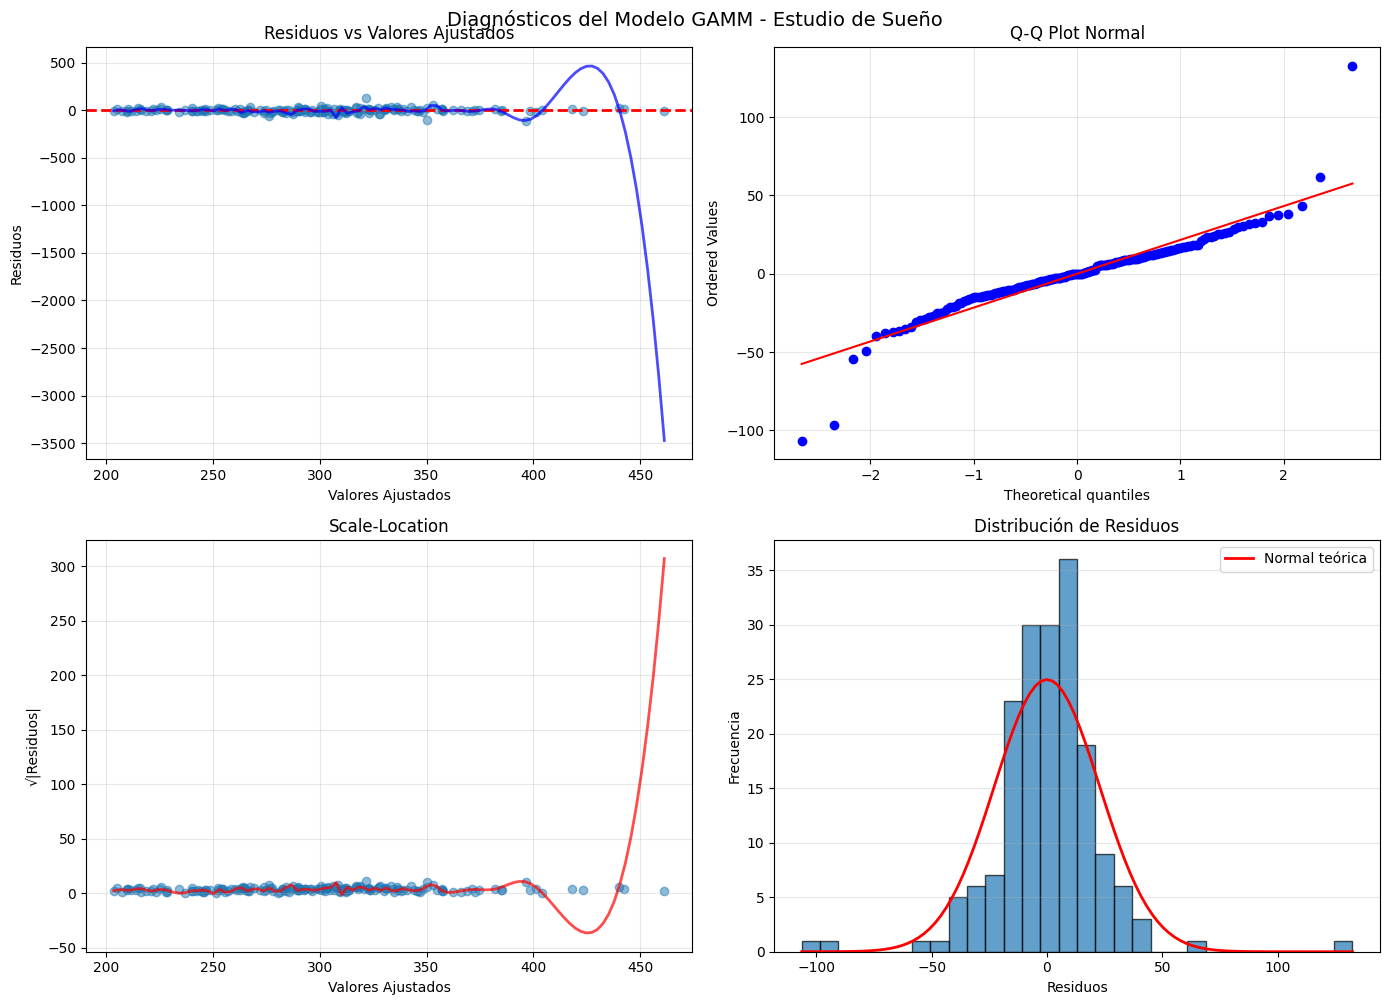


Interpretación de Diagnósticos:
1. Residuos vs Ajustados: Buscar patrones sistemáticos (idealmente aleatorio)
2. Q-Q Plot: Verificar normalidad de residuos (puntos cerca de la línea)
3. Scale-Location: Verificar homocedasticidad (varianza constante)
4. Histograma: Distribución de residuos debe ser aproximadamente normal


In [4]:
# Diagnostic plots
from aurora.models.gamm import plot_gamm_diagnostics

fig, axes = plot_gamm_diagnostics(result, figsize=(14, 10))
plt.suptitle('Diagnósticos del Modelo GAMM - Estudio de Sueño', fontsize=14, y=1.00)
plt.show()

print('\nInterpretación de Diagnósticos:')
print('1. Residuos vs Ajustados: Buscar patrones sistemáticos (idealmente aleatorio)')
print('2. Q-Q Plot: Verificar normalidad de residuos (puntos cerca de la línea)')
print('3. Scale-Location: Verificar homocedasticidad (varianza constante)')
print('4. Histograma: Distribución de residuos debe ser aproximadamente normal')